# ARTI 404 — Image Processing
## Lab 4: Intensity Transformations and Filtering in the Spatial Domain

**Student Name / ID:** Hassan (2240002973)  
**Course:** ARTI 404 — Image Processing  
**Session:** Lab 4 (Intensity Transformations and Histogram Processing)


## 1. Setup and Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure
from skimage.exposure import match_histograms
import os

print("OpenCV version   :", cv2.__version__)
print("NumPy version    :", np.__version__)


OpenCV version   : 5.0.0
NumPy version    : 2.5.1


---
## Procedural Steps (Tasks)

### Task #1: Thresholding with Fixed Thresholds
Apply thresholding with fixed threshold values ($0, 50, 100, 150, 200$) on an image.
Thresholding converts grayscale intensities into binary (foreground vs. background).


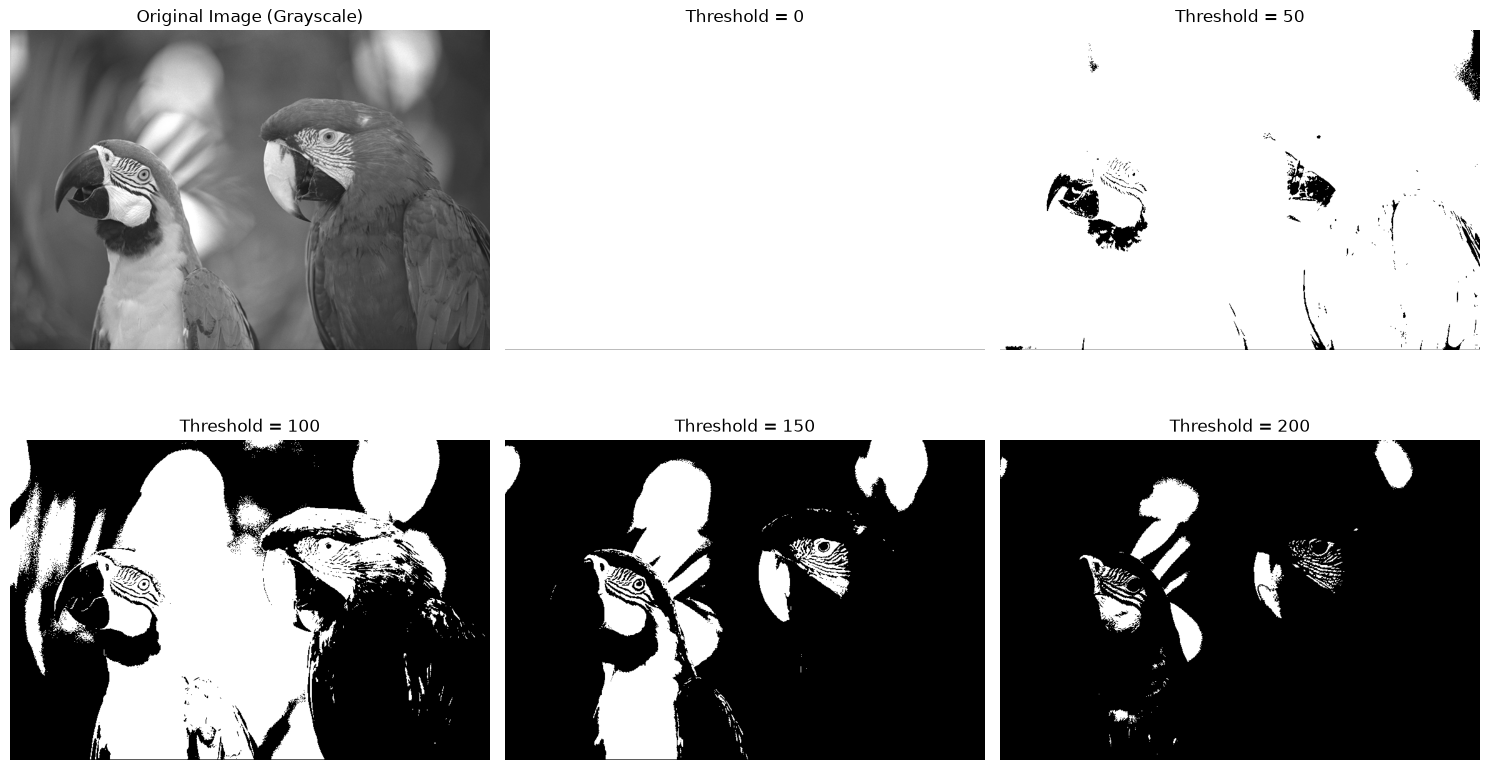

In [2]:
# Load image in grayscale
img_path = 'images/Parrot.png' if os.path.exists('images/Parrot.png') else '../images/Parrot.png'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

threshold_values = [0, 50, 100, 150, 200]

plt.figure(figsize=(15, 9))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image (Grayscale)', fontsize=12)
plt.axis('off')

# Thresholded images
for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 3, i + 2)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Threshold = {threshold_value}', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()


### Task #2: Histogram Processing — Contrast Stretching
Rescale intensity values of the Moon image to include intensities within the 2nd and 98th percentiles.


2nd percentile: 78.00, 98th percentile: 129.00


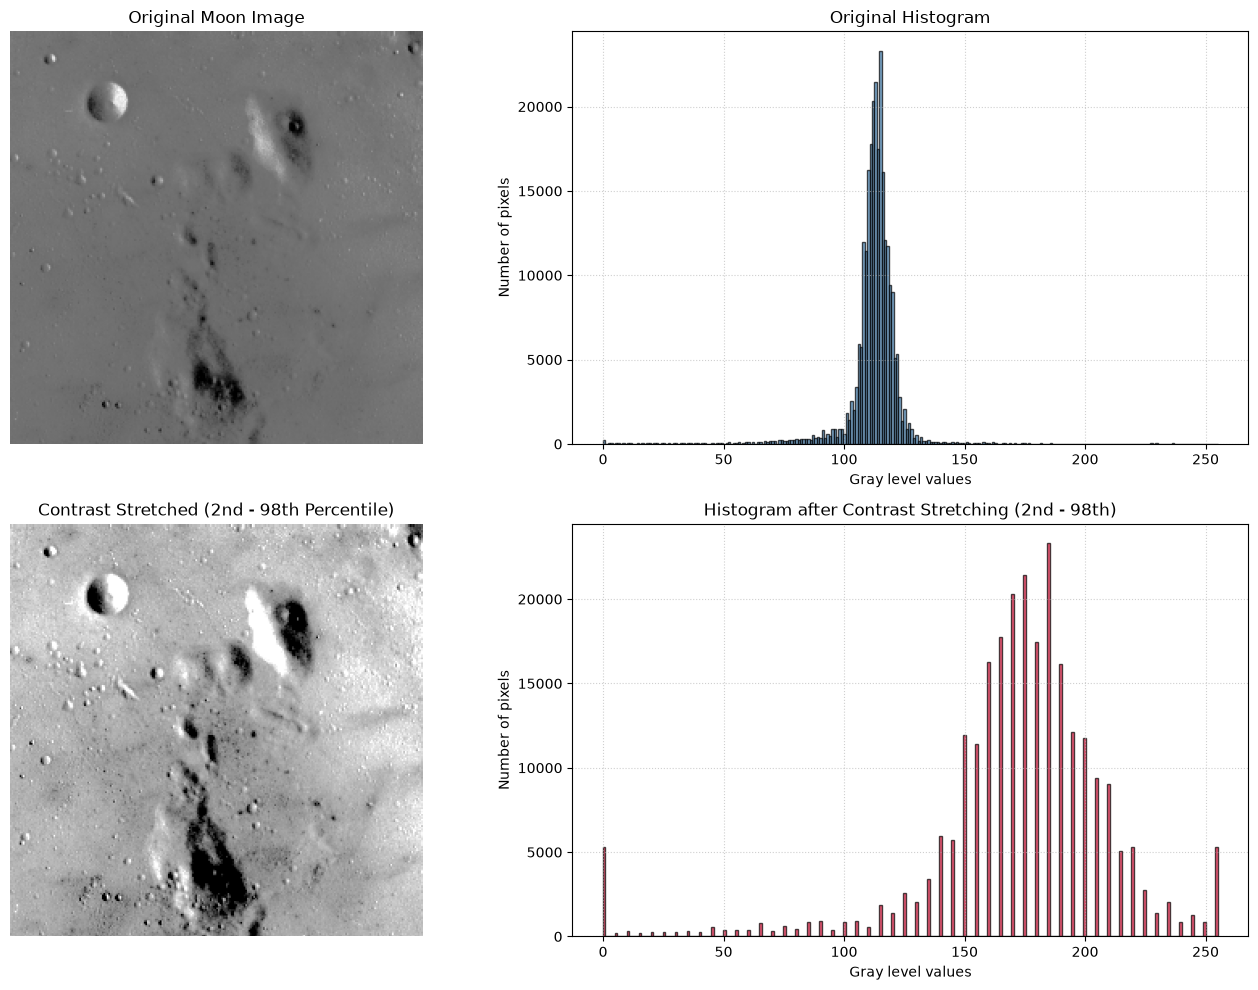

In [3]:
# Step 2: Load moon image
moon_img = data.moon()

# Step 3: Rescale intensity values (2nd to 98th percentiles)
p2, p98 = np.percentile(moon_img, (2, 98))
moon_rescale_2_98 = exposure.rescale_intensity(moon_img, in_range=(p2, p98))

print(f"2nd percentile: {p2:.2f}, 98th percentile: {p98:.2f}")

# Step 4: Display images and their histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original Moon
axes[0, 0].imshow(moon_img, cmap='gray')
axes[0, 0].set_title('Original Moon Image', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].hist(moon_img.flat, bins=256, range=(0, 255), color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Original Histogram', fontsize=12)
axes[0, 1].set_xlabel('Gray level values')
axes[0, 1].set_ylabel('Number of pixels')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# Contrast Stretched Moon (2nd - 98th)
axes[1, 0].imshow(moon_rescale_2_98, cmap='gray')
axes[1, 0].set_title('Contrast Stretched (2nd - 98th Percentile)', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].hist(moon_rescale_2_98.flat, bins=256, range=(0, 255), color='crimson', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Histogram after Contrast Stretching (2nd - 98th)', fontsize=12)
axes[1, 1].set_xlabel('Gray level values')
axes[1, 1].set_ylabel('Number of pixels')
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


---
## Assessment Tasks

### Assessment Task #1: Contrast Stretching with 3rd and 80th Percentiles
Using the Moon image, rescale intensity values within the 3rd and 80th percentiles and plot the image along with its histogram.


3rd percentile: 87.00, 80th percentile: 118.00


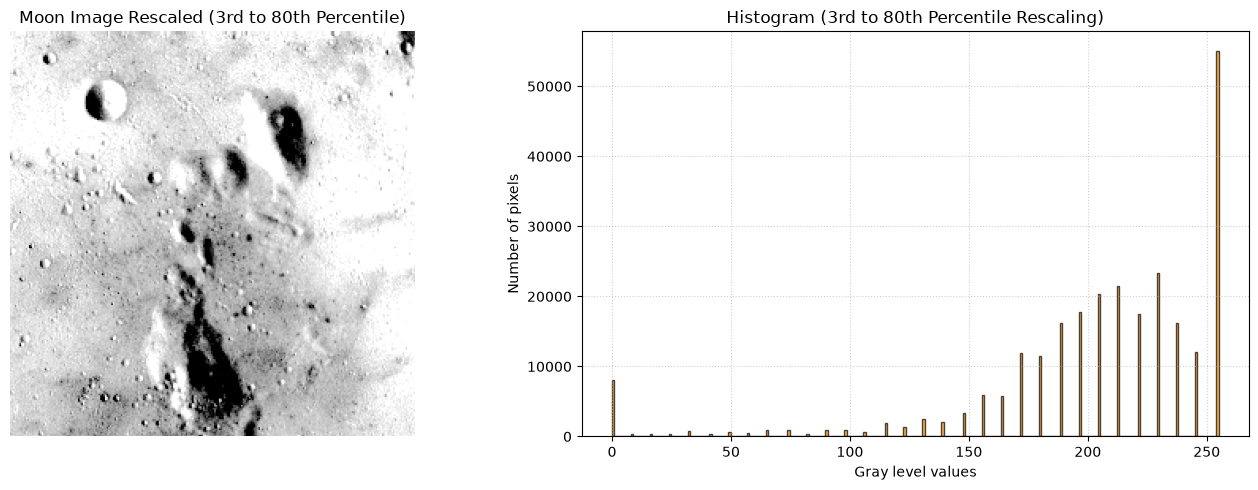

In [4]:
# Rescale intensity values between 3rd and 80th percentiles
p3, p80 = np.percentile(moon_img, (3, 80))
moon_rescale_3_80 = exposure.rescale_intensity(moon_img, in_range=(p3, p80))

print(f"3rd percentile: {p3:.2f}, 80th percentile: {p80:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Image
axes[0].imshow(moon_rescale_3_80, cmap='gray')
axes[0].set_title('Moon Image Rescaled (3rd to 80th Percentile)', fontsize=12)
axes[0].axis('off')

# Histogram
axes[1].hist(moon_rescale_3_80.flat, bins=256, range=(0, 255), color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_title('Histogram (3rd to 80th Percentile Rescaling)', fontsize=12)
axes[1].set_xlabel('Gray level values')
axes[1].set_ylabel('Number of pixels')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Assessment Task #2: Histogram Equalization
Using the Moon image and `skimage.exposure.equalize_hist`, flatten the histogram and display the equalized image and its flattened histogram.


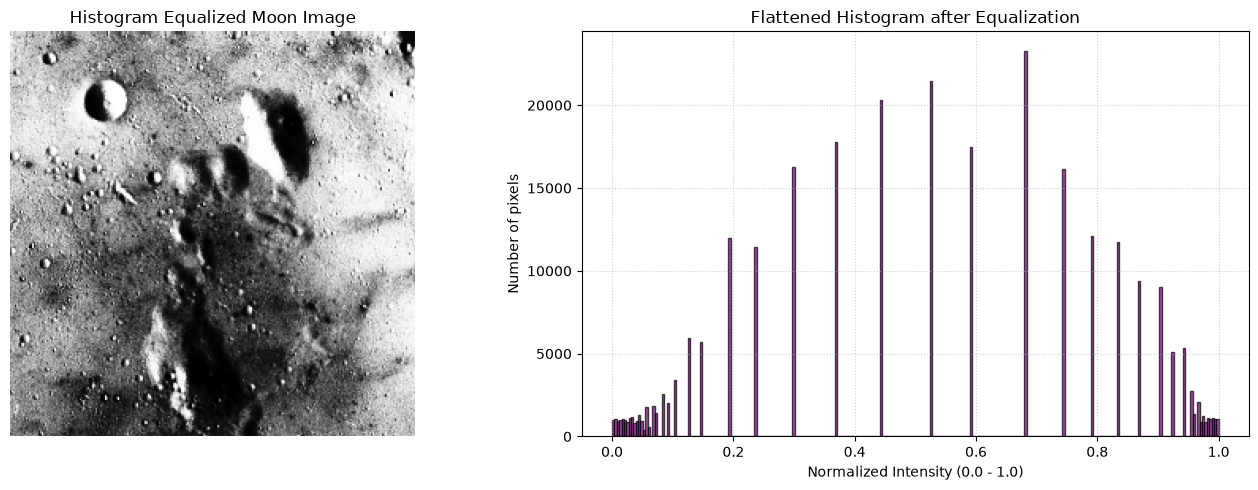

In [5]:
# Apply Histogram Equalization
moon_equalized = exposure.equalize_hist(moon_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Equalized image
axes[0].imshow(moon_equalized, cmap='gray')
axes[0].set_title('Histogram Equalized Moon Image', fontsize=12)
axes[0].axis('off')

# Flattened histogram
axes[1].hist(moon_equalized.ravel(), bins=256, range=(0, 1), color='purple', edgecolor='black', alpha=0.7)
axes[1].set_title('Flattened Histogram after Equalization', fontsize=12)
axes[1].set_xlabel('Normalized Intensity (0.0 - 1.0)')
axes[1].set_ylabel('Number of pixels')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Assessment Task #3: Histogram Matching (Specification)
Use the Rocket image as the reference and Chelsea (cat) image as the source from `skimage.data`, and implement histogram matching using `skimage.exposure.match_histograms`.


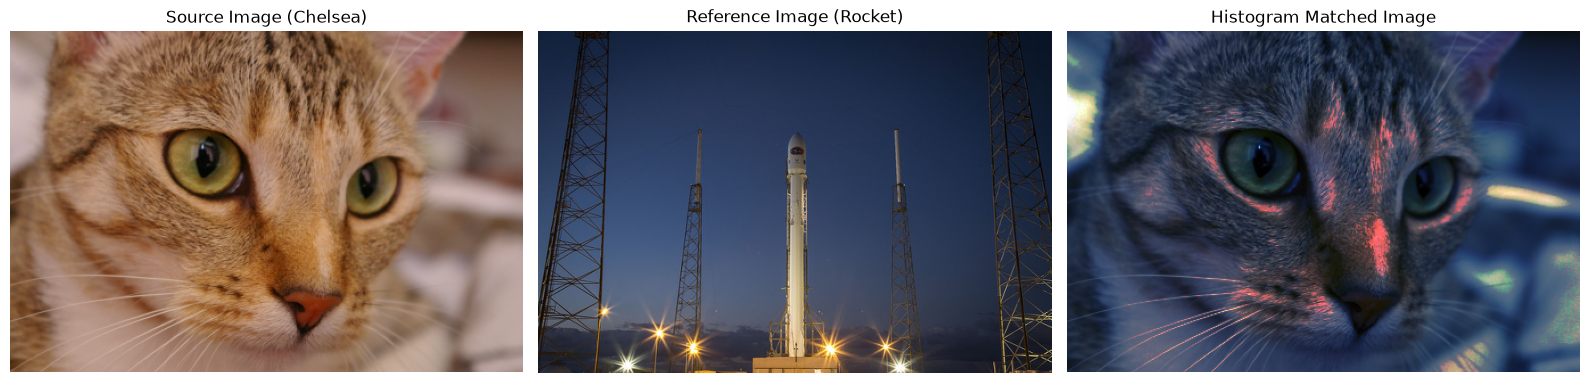

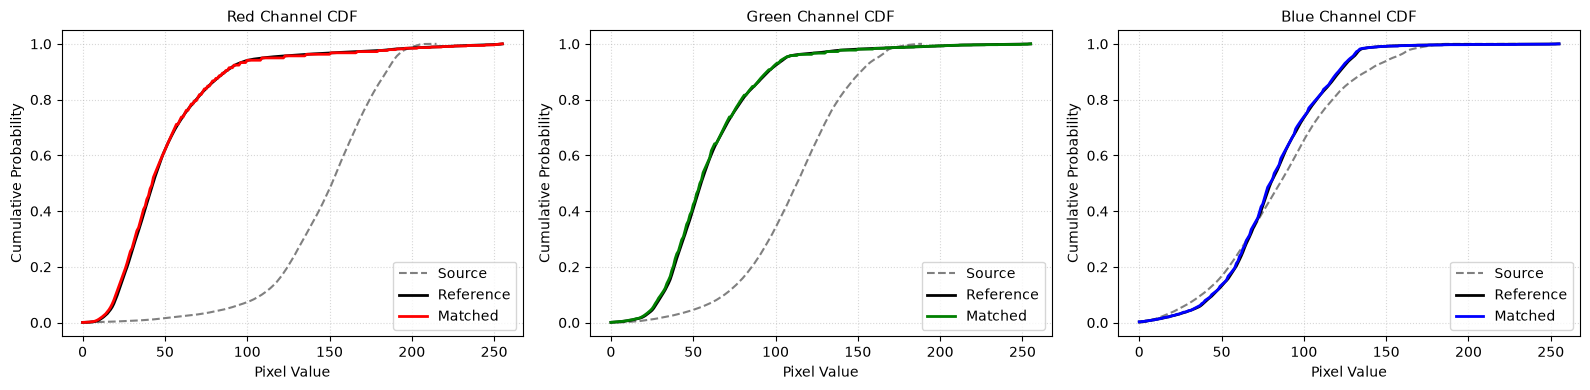

In [6]:
# Load source and reference images
image_source = data.chelsea()   # Source image (Chelsea cat)
image_reference = data.rocket() # Reference image (Rocket)

# Implement Histogram Matching across all color channels
matched_image = match_histograms(image_source, image_reference, channel_axis=-1)

# Display the source, reference, and matched images side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(image_source)
axes[0].set_title('Source Image (Chelsea)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(image_reference)
axes[1].set_title('Reference Image (Rocket)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(matched_image)
axes[2].set_title('Histogram Matched Image', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Display Cumulative Distribution Functions (CDF) to verify histogram matching
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
channels = ('Red', 'Green', 'Blue')
colors = ('red', 'green', 'blue')

for i, (col, cname) in enumerate(zip(colors, channels)):
    # Calculate CDFs
    hist_src, bins_src = exposure.cumulative_distribution(image_source[:, :, i])
    hist_ref, bins_ref = exposure.cumulative_distribution(image_reference[:, :, i])
    hist_mat, bins_mat = exposure.cumulative_distribution(matched_image[:, :, i])
    
    axes[i].plot(bins_src, hist_src, label='Source', color='gray', linestyle='--')
    axes[i].plot(bins_ref, hist_ref, label='Reference', color='black', lw=2)
    axes[i].plot(bins_mat, hist_mat, label='Matched', color=col, lw=2)
    axes[i].set_title(f'{cname} Channel CDF', fontsize=11)
    axes[i].set_xlabel('Pixel Value')
    axes[i].set_ylabel('Cumulative Probability')
    axes[i].legend(loc='lower right')
    axes[i].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()
